# Setup

### Imports

In [59]:
# ---- Standard libraries ----
import os
import sys
import json
import csv
import time
import math
import ast
import copy
import heapq
import random
import pickle
import logging
from datetime import datetime
from collections import defaultdict, namedtuple, deque
from itertools import permutations

# ---- Data manipulation / visualization ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm

# ---- Geo-related ----
import geojson
import geopandas as gpd
from shapely.geometry import Point, Polygon
from alphashape import alphashape
import geopy.distance
import networkx as nx
import requests
import overpass  # Overpass API for OpenStreetMap queries

# ---- PyTorch (for RL/deep learning parts) ----
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ---- Removed: this line (was for Colab only) ----
# from google.colab import drive


In [60]:
state_name = "Ohio"
city_name = "Columbus"
mini = True

### Paths

In [61]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

# Local data folder
DATA_DIR = PROJECT_ROOT / "Delivery_Data"
DATA_DIR.mkdir(exist_ok=True)

print(f"Using data directory: {DATA_DIR}")

Using data directory: /root/UMST_approach/Delivery_Data


In [62]:
# --- 5. Set Directories (local/cloud version) ---
from pathlib import Path
import os

try:
    # Step 1: base path (one level up from "Source Code/")
    personal_dir = str(Path.cwd().parent / "Delivery_Data") + "/"

    # Step 2: data folder based on city_name and mini flag
    data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"

    # Step 3: output folder (same structure as before)
    output_dir = data_dir + "/UMST Graph/maddpg_baseline"

    # Step 4: create output directory if missing
    os.makedirs(output_dir, exist_ok=True)

    # Step 5: print info
    print(f"Data directory: {data_dir}")
    print(f"Output directory: {output_dir}")

    # Step 6: list contents for sanity check
    data = os.listdir(data_dir)
    print(f"Files in data_dir: {data}")

except Exception as e:
    print(f"Error setting up directories: {e}")
    print(f"Personal Dir Path: {personal_dir}")
    print(f"Data Dir Path: {data_dir}")

Data directory: /root/UMST_approach/Delivery_Data/Columbus_mini - RL Delivery Data
Output directory: /root/UMST_approach/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/maddpg_baseline
Files in data_dir: ['Images', 'Deliveries', 'Processed Location Data', 'Q Tables', 'avg_hotspot_data.json', 'Census Data', 'results_fixed_buffer', 'results_multiply', 'gh_cache', 'UMST Graph', 'Original Location Data', 'results_rangewise', 'results_randomized', 'Hotspot Data']


In [63]:
graph_path = data_dir + "/UMST Graph/graphs"
full_graph = graph_path + "/gh_hotspot_graph.graphml.xml"
umst_graph = graph_path + "/umst_graph.graphml.xml"

### Sanity Check

In [64]:
import networkx as nx
import numpy as np

def verify_hotspot_graph(graph_path):
    """
    Load and verify the hotspot graph.
    Ensures node and edge attributes are valid and consistent.
    Returns: nx.Graph object if valid.
    """
    print(f"\n📂 Loading graph from: {graph_path}")
    try:
        G = nx.read_graphml(graph_path)
    except Exception as e:
        raise ValueError(f"❌ Failed to load graph: {e}")

    # Basic info
    print(f"✓ Graph loaded successfully.")
    print(f"   → {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Node checks ---
    missing_latlon = [
        n for n, d in G.nodes(data=True)
        if 'lat' not in d or 'lon' not in d
    ]
    if missing_latlon:
        raise ValueError(f"❌ Some nodes missing lat/lon: {missing_latlon[:5]}")
    else:
        print(f"✓ All nodes have lat/lon attributes.")

    # --- Edge checks ---
    bad_edges = []
    distances, times = [], []
    for u, v, d in G.edges(data=True):
        dist = float(d.get('distance', np.nan))
        time = float(d.get('time', np.nan))
        if np.isnan(dist) or np.isnan(time) or dist <= 0 or time <= 0:
            bad_edges.append((u, v, d))
        else:
            distances.append(dist)
            times.append(time)

    if bad_edges:
        print(f"⚠️ Found {len(bad_edges)} edges with invalid data. Showing first 3:")
        for e in bad_edges[:3]:
            print("   ", e)
    else:
        print(f"✓ All edges have valid distance/time attributes.")

    print(f"📊 Mean distance: {np.mean(distances):.2f} km")
    print(f"📊 Mean travel time: {np.mean(times):.1f} mins")
    sample_edge = list(G.edges(data=True))[0]
    print(f"🔍 Sample edge: {sample_edge}")

    return G


In [65]:
G = verify_hotspot_graph(umst_graph)


📂 Loading graph from: /root/UMST_approach/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/umst_graph.graphml.xml
✓ Graph loaded successfully.
   → 26 nodes, 47 edges
✓ All nodes have lat/lon attributes.
✓ All edges have valid distance/time attributes.
📊 Mean distance: 1.80 km
📊 Mean travel time: 4.1 mins
🔍 Sample edge: ('39049001110', '39049001000', {'weight': 0.7133257288090575, 'distance': 1.016, 'time': 3.45, 'mst_frequency': 36, 'frequency_ratio': 0.9})


# Delivery Class

In [66]:
# Delivery and DeliveryList classes for your notebook
# This cell defines a clean, self-contained Delivery model that we'll use for the MADDPG env.
from dataclasses import dataclass, field
from typing import Optional, List, Dict, Any
import pickle
import os

@dataclass
class Delivery:
    id: int
    pickup: Any           # node id (string or int depending on your graph)
    dropoff: Any          # node id
    status: str = "waiting"  # one of: waiting, assigned, in_transit, completed, cancelled
    owner: Optional[int] = None    # agent_id if assigned (None if not)
    created_at_step: Optional[int] = None
    picked_at_step: Optional[int] = None
    delivered_at_step: Optional[int] = None
    metadata: Dict = field(default_factory=dict)
    
    def assign_to_agent(self, agent_id: int, step: Optional[int]=None):
        self.owner = agent_id
        self.status = "assigned"
        if step is not None:
            self.picked_at_step = step
    
    def start_transport(self, step: Optional[int]=None):
        self.status = "in_transit"
        if step is not None and self.picked_at_step is None:
            self.picked_at_step = step
    
    def complete(self, step: Optional[int]=None):
        self.status = "completed"
        if step is not None:
            self.delivered_at_step = step
    
    def to_dict(self):
        return {
            "id": self.id,
            "pickup": self.pickup,
            "dropoff": self.dropoff,
            "status": self.status,
            "owner": self.owner,
            "metadata": self.metadata
        }
    
    def __repr__(self):
        return f"Delivery(id={self.id}, {self.pickup}->{self.dropoff}, status={self.status}, owner={self.owner})"



In [67]:
class DeliveryList:
    """
    A small manager/wrapper around a list of Delivery objects.
    Provides convenience lookups by node (pickup map) and by id.
    """
    def __init__(self, deliveries: Optional[List[Delivery]] = None):
        self.deliveries: List[Delivery] = deliveries[:] if deliveries else []
        self.by_id: Dict[int, Delivery] = {d.id: d for d in self.deliveries}
        self.pickup_map: Dict[Any, List[int]] = {}   # node -> list of delivery ids (waiting)
        self._rebuild_pickup_map()
    
    def _rebuild_pickup_map(self):
        self.pickup_map = {}
        for d in self.deliveries:
            if d.status == "waiting":
                self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def add_delivery(self, d: Delivery):
        if d.id in self.by_id:
            raise ValueError("delivery id exists")
        self.deliveries.append(d)
        self.by_id[d.id] = d
        if d.status == "waiting":
            self.pickup_map.setdefault(d.pickup, []).append(d.id)
    
    def pop_next_for_node(self, node_id: Any) -> Optional[Delivery]:
        """Deterministic pop: return the first waiting delivery id for node (or None)."""
        lst = self.pickup_map.get(node_id, [])
        if not lst:
            return None
        did = lst.pop(0)
        d = self.by_id[did]
        # update status here if desired
        return d
    
    def assign_delivery_to_agent(self, delivery_id: int, agent_id: int, step: Optional[int]=None):
        d = self.by_id[delivery_id]
        if d.status != "waiting":
            raise RuntimeError("Trying to assign non-waiting delivery")
        d.assign_to_agent(agent_id, step=step)
        # remove from pickup_map
        lst = self.pickup_map.get(d.pickup, [])
        if delivery_id in lst:
            lst.remove(delivery_id)
    
    def remaining_count(self):
        return sum(1 for d in self.deliveries if d.status in ("waiting", "assigned", "in_transit"))
    
    def get_waiting_at_node(self, node_id: Any) -> List[int]:
        return list(self.pickup_map.get(node_id, []))
    
    def to_simple_list(self):
        return [d.to_dict() for d in self.deliveries]

In [68]:
# Display the class definitions so you can copy/paste this into your notebook cell.
Delivery, DeliveryList


(__main__.Delivery, __main__.DeliveryList)

## Generate Deliveries

In [69]:
import random

def generate_simple_deliveries(G, num_deliveries=1000, seed=42):
    """
    Simplified random delivery generator.
    Creates num_deliveries random (pickup, dropoff) pairs from the graph nodes.
    No time/distance filtering; uses your verified full graph.
    """
    random.seed(seed)
    nodes = list(G.nodes())
    deliveries = []

    for i in range(num_deliveries):
        pickup, dropoff = random.sample(nodes, 2)  # ensure pickup != dropoff
        deliveries.append(Delivery(id=i, pickup=pickup, dropoff=dropoff, status="waiting"))

    delivery_list = DeliveryList(deliveries)
    print(f"✅ Generated {num_deliveries} deliveries between {len(nodes)} nodes.")
    print(f"Example: {deliveries[0]}")
    return delivery_list


In [70]:
import matplotlib.pyplot as plt

def plot_deliveries_on_graph(G, delivery_list, sample_size=100):
    """
    Quick visual check: plots the hotspot graph (using lat/lon)
    and overlays sampled pickup → dropoff connections.
    """
    plt.figure(figsize=(10, 8))

    # Extract positions from node lat/lon
    pos = {n: (float(d['lon']), float(d['lat'])) for n, d in G.nodes(data=True)}

    # Draw the base graph (light gray edges, small nodes)
    nx.draw_networkx_edges(G, pos, edge_color='lightgray', alpha=0.5, width=0.8)
    nx.draw_networkx_nodes(G, pos, node_size=40, node_color='gray')

    # Sample deliveries to display (avoid clutter)
    sample_deliveries = random.sample(delivery_list.deliveries, min(sample_size, len(delivery_list.deliveries)))

    for d in sample_deliveries:
        pickup_pos = pos[d.pickup]
        dropoff_pos = pos[d.dropoff]
        plt.plot(
            [pickup_pos[0], dropoff_pos[0]],
            [pickup_pos[1], dropoff_pos[1]],
            color='tab:blue', alpha=0.6, linewidth=1.5
        )
        plt.scatter(*pickup_pos, color='green', s=30, zorder=5)
        plt.scatter(*dropoff_pos, color='red', s=30, zorder=5)

    plt.title(f"Sample of {len(sample_deliveries)} Deliveries (Pickup=Green, Dropoff=Red)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()


# Delivery Enviornment: 
literaly handles everything

In [71]:
# -------------------- Silent DeliveryEnvironment --------------------
import networkx as nx
import numpy as np
import random
from typing import Dict, Any, List, Optional, Tuple

STATE_EMPTY = 0
STATE_ONE = 1
STATE_TWO = 2
STATE_GOING_TO_AGENT = 3
STATE_BEING_APPROACHED = 4
STATE_POST_FIRST = 5

class DeliveryEnvironment:
    def __init__(self, G: nx.Graph, delivery_list: 'DeliveryList', num_agents: int = 10, seed: int = 42):
        random.seed(seed)
        np.random.seed(seed)
        self.G = G
        self.node_list = list(G.nodes())
        self.node_index = {n:i for i,n in enumerate(self.node_list)}
        self.N_nodes = len(self.node_list)

        self.distance_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)
        self.time_matrix = np.full((self.N_nodes, self.N_nodes), np.inf)

        for i,u in enumerate(self.node_list):
            length_dist = nx.single_source_dijkstra_path_length(self.G, u, weight='distance')
            length_time = nx.single_source_dijkstra_path_length(self.G, u, weight='time')
            for v,val in length_dist.items():
                j = self.node_index[v]
                self.distance_matrix[i,j] = val
            for v,val in length_time.items():
                j = self.node_index[v]
                self.time_matrix[i,j] = val

        finite_max = np.nanmax(self.distance_matrix[np.isfinite(self.distance_matrix)]) if np.any(np.isfinite(self.distance_matrix)) else 1.0
        self.distance_matrix[~np.isfinite(self.distance_matrix)] = finite_max * 10.0
        self.time_matrix[~np.isfinite(self.time_matrix)] = np.nanmax(self.time_matrix[np.isfinite(self.time_matrix)]) * 10.0 if np.any(np.isfinite(self.time_matrix)) else 1.0

        self.max_pair_dist = float(np.max(self.distance_matrix))

        self.delivery_list = delivery_list
        self.pickup_map = dict(self.delivery_list.pickup_map)

        self.num_agents = num_agents
        self.agents = {}
        self._init_agents_random()

        self.step_count = 0
        self.episode_stats = {
            'total_deliveries': 0,
            'bundles_created': 0,
            'distance_saved_sum': 0.0,
            'bundle_attempts': 0,
            'successful_bundles': 0,
        }
        self.active_bundle_attempts = {}

    def _init_agents_random(self):
        self.agents = {}
        nodes = self.node_list[:]
        for aid in range(self.num_agents):
            node = random.choice(nodes)
            self.agents[aid] = {
                'current_node': node,
                'state': STATE_EMPTY,
                'deliveries': [],
                'path_queue': [],
                'target_agent': None,
                'being_reached': False,
            }

        available_waiting = [d.id for d in self.delivery_list.deliveries if d.status == 'waiting']
        for aid in range(self.num_agents):
            if not available_waiting:
                break
            did = available_waiting.pop(0)
            self.delivery_list.assign_delivery_to_agent(did, aid, step=0)
            self.agents[aid]['deliveries'].append(did)
            self.agents[aid]['state'] = STATE_ONE
            d = self.delivery_list.by_id[did]
            self.agents[aid]['path_queue'] = self._shortest_path_nodes(self.agents[aid]['current_node'], d.dropoff)

    def _assign_nearest_deliveries_to_empty_agents(self):
        waiting = [d for d in self.delivery_list.deliveries if d.status == "waiting"]
        if not waiting:
            return

        for aid, info in self.agents.items():
            if info['state'] == STATE_EMPTY and not info['being_reached']:
                cur_node = info['current_node']
                cur_idx = self.node_index[cur_node]
                best_d, best_del = float('inf'), None
                for d in waiting:
                    pick_idx = self.node_index[d.pickup]
                    dist = self.distance_matrix[cur_idx, pick_idx]
                    if dist < best_d:
                        best_d, best_del = dist, d

                if best_del is not None:
                    self.delivery_list.assign_delivery_to_agent(best_del.id, aid, step=self.step_count)
                    waiting.remove(best_del)
                    info['deliveries'].append(best_del.id)
                    info['state'] = STATE_ONE
                    info['path_queue'] = self._shortest_path_nodes(cur_node, best_del.pickup)

    def _shortest_path_nodes(self, src, dst) -> List[Any]:
        try:
            path = nx.shortest_path(self.G, source=src, target=dst, weight='distance')
            return path[1:]
        except Exception:
            return []

    def reset(self):
        """Fully reset the environment and restore deliveries to 'waiting'."""
        self.step_count = 0
        self.active_bundle_attempts.clear()

        # Reset all deliveries to waiting
        for d in self.delivery_list.deliveries:
            d.status = "waiting"
            d.assigned_agent = None
            d.completed_step = None

        # Rebuild pickup map
        self.pickup_map = dict(self.delivery_list.pickup_map)

        # Reset episode stats
        for k in self.episode_stats:
            self.episode_stats[k] = 0

        # Reinitialize agents and assign first deliveries
        self._init_agents_random()
        self._assign_nearest_deliveries_to_empty_agents()

        # Return initial observations
        return self._get_observations()


    def _get_observations(self) -> Dict[int, Optional[np.ndarray]]:
        obs = {}
        for aid, info in self.agents.items():
            if info['state'] != STATE_ONE:
                obs[aid] = None
                continue

            did = info['deliveries'][0]
            d = self.delivery_list.by_id[did]
            n_self = self.node_index[info['current_node']]
            n_drop = self.node_index[d.dropoff]
            d_self_dropoff = float(self.distance_matrix[n_self, n_drop])

            nearest, nearest_dist = None, float('inf')
            for oid, oinfo in self.agents.items():
                if oid == aid or oinfo['state'] != STATE_ONE:
                    continue
                dist = float(self.distance_matrix[n_self, self.node_index[oinfo['current_node']]])
                if dist < nearest_dist:
                    nearest_dist = dist
                    nearest = oid

            if nearest is None:
                obs[aid] = None
                continue

            other_did = self.agents[nearest]['deliveries'][0]
            other_drop_node = self.delivery_list.by_id[other_did].dropoff
            d_other_dropoff = float(self.distance_matrix[self.node_index[self.agents[nearest]['current_node']], self.node_index[other_drop_node]])

            obs_vec = np.array([d_self_dropoff, nearest_dist, d_other_dropoff], dtype=np.float32)
            obs[aid] = obs_vec
        return obs

    def _move_agent_along_path(self, aid):
        info = self.agents[aid]
        if info['path_queue']:
            next_node = info['path_queue'].pop(0)
            info['current_node'] = next_node

    # def compute_bundle_reward(self, proposer_id: int, receiver_id: int) -> float:
    #     A = self.agents[proposer_id]
    #     B = self.agents[receiver_id]
    #     did_a = A['deliveries'][0]
    #     did_b = B['deliveries'][0]
    #     nA = self.node_index[A['current_node']]
    #     nB = self.node_index[B['current_node']]
    #     dA = self.node_index[self.delivery_list.by_id[did_a].dropoff]
    #     dB = self.node_index[self.delivery_list.by_id[did_b].dropoff]
    #     dist_nA_dA = float(self.distance_matrix[nA, dA])
    #     dist_nB_dB = float(self.distance_matrix[nB, dB])
    #     dist_dB_dA = float(self.distance_matrix[dB, dA])
    #     initial_total = dist_nA_dA + dist_nB_dB
    #     new_total = dist_nB_dB + dist_dB_dA
    #     distance_saved = initial_total - new_total
    #     normalized = max(-2.0, min(2.0, distance_saved / (self.max_pair_dist + 1e-9)))
    #     return 5.0 + 5.0 * normalized
    def compute_bundle_reward(self, proposer_id: int, receiver_id: int) -> float:
        saved = self._compute_pair_saving(proposer_id, receiver_id)
        # normalize by max_pair_dist (as you did)
        normalized = saved / (self.max_pair_dist + 1e-9)
        normalized = max(-2.0, min(2.0, normalized))
        r = 5.0 + 5.0 * normalized
        # optional debug:
        # print(f"[BundleReward] proposer={proposer_id}, receiver={receiver_id}, saved={saved:.3f}, r={r:.3f}")
        return r


    def handle_bundling_request(self, proposer_id: int, receiver_id: int):
        P = self.agents[proposer_id]
        R = self.agents[receiver_id]
        P['state'] = STATE_GOING_TO_AGENT
        P['target_agent'] = receiver_id
        P['path_queue'] = self._shortest_path_nodes(P['current_node'], R['current_node'])
        R['being_reached'] = True
        R['state'] = STATE_BEING_APPROACHED
        self.active_bundle_attempts[proposer_id] = (receiver_id, self.step_count)
        self.episode_stats['bundle_attempts'] += 1

    def _finalize_transfer(self, proposer_id: int, receiver_id: int):
        P = self.agents[proposer_id]
        R = self.agents[receiver_id]
        if not P['deliveries'] or not R['deliveries']:
            return False
        did = P['deliveries'].pop(0)
        R['deliveries'].append(did)
        self.delivery_list.by_id[did].assign_to_agent(receiver_id, step=self.step_count)
        P['state'] = STATE_EMPTY
        P['target_agent'] = None
        R['state'] = STATE_TWO
        R['being_reached'] = False
        first_did = R['deliveries'][0]
        first_drop = self.delivery_list.by_id[first_did].dropoff
        R['path_queue'] = self._shortest_path_nodes(R['current_node'], first_drop)
        self.episode_stats['bundles_created'] += 1
        self.episode_stats['successful_bundles'] += 1
        self.active_bundle_attempts.pop(proposer_id, None)
        return True

    def _process_arrivals_and_pickups(self):
        node_agents = {}
        for aid, info in self.agents.items():
            node_agents.setdefault(info['current_node'], []).append(aid)

        rewards = {aid: 0.0 for aid in self.agents.keys()}
        for node, agent_ids in node_agents.items():
            waiting = self.pickup_map.get(node, [])
            if not waiting:
                continue
            agent_ids_sorted = sorted(agent_ids)
            winner = None
            for aid in agent_ids_sorted:
                info = self.agents[aid]
                if info['state'] == STATE_EMPTY and not info['being_reached']:
                    winner = aid
                    break
            if winner is None:
                continue
            did = waiting.pop(0)
            self.delivery_list.assign_delivery_to_agent(did, winner, step=self.step_count)
            self.agents[winner]['deliveries'].append(did)
            self.agents[winner]['state'] = STATE_ONE
            drop = self.delivery_list.by_id[did].dropoff
            self.agents[winner]['path_queue'] = self._shortest_path_nodes(self.agents[winner]['current_node'], drop)
        return rewards
    def _compute_pair_saving(self, proposer_id: int, receiver_id: int) -> float:
        """
        Compute (distance_before - distance_after) for proposer A and receiver B.
        Uses the precomputed self.distance_matrix (km).
        Returns a signed float: positive => saved distance, negative => increases distance.
        """
        A = self.agents[proposer_id]
        B = self.agents[receiver_id]
        # assume each currently has exactly one delivery (safe-guard if not)
        if not A['deliveries'] or not B['deliveries']:
            return 0.0

        did_a = A['deliveries'][0]
        did_b = B['deliveries'][0]
        nA = self.node_index[A['current_node']]
        nB = self.node_index[B['current_node']]
        dA = self.node_index[self.delivery_list.by_id[did_a].dropoff]
        dB = self.node_index[self.delivery_list.by_id[did_b].dropoff]

        # before: separate trips
        total_before = float(self.distance_matrix[nA, dA] + self.distance_matrix[nB, dB])

        # proposer needs to travel to receiver to handover
        proposer_to_receiver = float(self.distance_matrix[nA, nB])

        # receiver must do both dropoffs; try both orderings and pick best
        # order1: B -> A
        r1 = float(self.distance_matrix[nB, dB] + self.distance_matrix[dB, dA])
        # order2: A -> B (maybe receiver goes to A first)
        r2 = float(self.distance_matrix[nB, dA] + self.distance_matrix[dA, dB])
        best_receiver_route = min(r1, r2)

        total_after = proposer_to_receiver + best_receiver_route

        saved = total_before - total_after
        return saved

    def step(self, actions: Optional[Dict[int, int]] = None, max_steps: Optional[int] = None) -> Tuple[
        Dict[int, Optional[np.ndarray]], Dict[int, float], bool, Dict]:
        """
        Single environment step.
        `actions` is a dict mapping agent_id -> action (only for agents in STATE_ONE):
        action 0 or omitted -> continue toward own dropoff
        action 1 -> attempt bundling (propose to nearest agent in STATE_ONE)
        """
        self.step_count += 1
        if actions is None:
            actions = {}

        rewards = {aid: 0.0 for aid in self.agents.keys()}

        # 1) --- Decision Stage ---
        for aid in sorted(self.agents.keys()):
            info = self.agents[aid]

            if info['state'] == STATE_ONE:
                # find nearest other STATE_ONE agent
                nearest, nearest_dist = None, float('inf')
                for oid, oinfo in self.agents.items():
                    if oid == aid:
                        continue
                    if oinfo['state'] != STATE_ONE:
                        continue
                    dist = float(self.distance_matrix[self.node_index[info['current_node']],
                                                    self.node_index[oinfo['current_node']]])
                    if dist < nearest_dist:
                        nearest_dist, nearest = dist, oid

                if nearest is None:
                    # no partner found, continue to own dropoff
                    if not info['path_queue']:
                        did = info['deliveries'][0]
                        drop = self.delivery_list.by_id[did].dropoff
                        info['path_queue'] = self._shortest_path_nodes(info['current_node'], drop)
                    continue

                # get action for this agent (0=continue, 1=propose bundle)
                act = actions.get(aid, 0)
                if act == 1:
                    # propose to nearest available STATE_ONE agent
                    if self.agents[nearest]['state'] == STATE_ONE and not self.agents[nearest]['being_reached']:
                        self.handle_bundling_request(aid, nearest)
                        r = self.compute_bundle_reward(aid, nearest)
                        rewards[aid] += r
                        rewards[nearest] += r

                        # track distance saved
                        A, B = self.agents[aid], self.agents[nearest]
                        did_a, did_b = A['deliveries'][0], B['deliveries'][0]
                        nA, nB = self.node_index[A['current_node']], self.node_index[B['current_node']]
                        dA = self.node_index[self.delivery_list.by_id[did_a].dropoff]
                        dB = self.node_index[self.delivery_list.by_id[did_b].dropoff]

                        initial_total = float(self.distance_matrix[nA, dA] + self.distance_matrix[nB, dB])
                        new_total = float(self.distance_matrix[nB, dB] + self.distance_matrix[dB, dA])
                        saved = initial_total - new_total

                        self.episode_stats['distance_saved_sum'] += saved
                        self.episode_stats['bundle_attempts'] += 0  # already counted elsewhere
                else:
                    # continue to dropoff if no path
                    if not info['path_queue']:
                        did = info['deliveries'][0]
                        drop = self.delivery_list.by_id[did].dropoff
                        info['path_queue'] = self._shortest_path_nodes(info['current_node'], drop)
            # else: other states handled in movement

        # assign new deliveries to idle (STATE_EMPTY) agents
        self._assign_nearest_deliveries_to_empty_agents()

        # 2) --- Movement Stage ---
        for aid in sorted(self.agents.keys()):
            info = self.agents[aid]
            if info['state'] == STATE_BEING_APPROACHED:
                continue
            self._move_agent_along_path(aid)

        # 3) --- Bundling arrivals ---
        for proposer_id, (receiver_id, start_step) in list(self.active_bundle_attempts.items()):
            if self.agents[proposer_id]['current_node'] == self.agents[receiver_id]['current_node']:
                self._finalize_transfer(proposer_id, receiver_id)

        # 4) --- Pickups ---
        pickup_rewards = self._process_arrivals_and_pickups()
        for k, v in pickup_rewards.items():
            rewards[k] += v

        # 5) --- Dropoffs (delivery completions) ---
        for aid, info in self.agents.items():
            if info['deliveries']:
                first_did = info['deliveries'][0]
                drop_node = self.delivery_list.by_id[first_did].dropoff
                if info['current_node'] == drop_node:
                    self.delivery_list.by_id[first_did].complete(step=self.step_count)
                    rewards[aid] += 5.0  # completion bonus
                    info['deliveries'].pop(0)

                    # update state
                    if info['state'] == STATE_TWO:
                        info['state'] = STATE_POST_FIRST
                        if info['deliveries']:
                            next_drop = self.delivery_list.by_id[info['deliveries'][0]].dropoff
                            info['path_queue'] = self._shortest_path_nodes(info['current_node'], next_drop)
                    elif info['state'] == STATE_POST_FIRST:
                        info['state'] = STATE_EMPTY
                        info['path_queue'] = []
                    else:
                        info['state'] = STATE_EMPTY
                        info['path_queue'] = []

                    self.episode_stats['total_deliveries'] += 1

        # 6) --- Termination check ---
        done = False
        if max_steps is not None and self.step_count >= max_steps:
            done = True
        if self.delivery_list.remaining_count() == 0:
            done = True

        if done:
            for proposer_id, (receiver_id, _) in list(self.active_bundle_attempts.items()):
                rewards[proposer_id] += -0.5
                rewards[receiver_id] += -0.5
            self.active_bundle_attempts.clear()

        # 7) --- Next observations ---
        obs = self._get_observations()
        info = {'step': self.step_count, 'episode_stats': dict(self.episode_stats)}
        return obs, rewards, done, info


In [72]:
deliveries = generate_simple_deliveries(G, num_deliveries=100)
env = DeliveryEnvironment(G, deliveries, num_agents=10)

✅ Generated 100 deliveries between 26 nodes.
Example: Delivery(id=0, 39049001600->39049007830, status=waiting, owner=None)


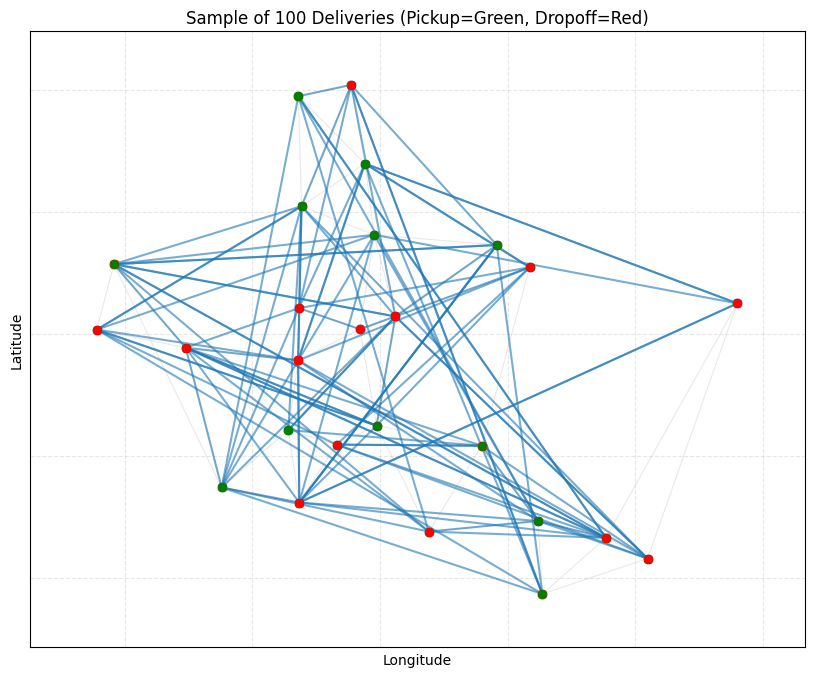

In [73]:
# Example usage (run after generating deliveries)
plot_deliveries_on_graph(G, deliveries, sample_size=100)

# MADDPG Agent and Agent Coordinator

In [74]:
# ------------------ Cell A: MADDPGAgent (PyTorch) + ReplayBuffer ------------------
# Requires: torch, nn, F, optim, numpy, random, collections (namedtuple, deque)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Transition = namedtuple('Transition', [
    'obs_self', 'obs_other',
    'action_self', 'action_other',
    'reward_self', 'reward_other',
    'next_obs_self', 'next_obs_other',
    'done'
])

class ReplayBuffer:
    def __init__(self, capacity=200000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(Transition(*args))
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    
    def __len__(self):
        return len(self.buffer)

# simple MLP factory
def mlp(input_dim, hidden_dims, output_dim, final_activation=None):
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(prev, h))
        layers.append(nn.ReLU())
        prev = h
    layers.append(nn.Linear(prev, output_dim))
    if final_activation == 'tanh':
        layers.append(nn.Tanh())
    return nn.Sequential(*layers)

class Actor(nn.Module):
    def __init__(self, obs_dim=3, hidden=(128,64)):
        super().__init__()
        self.net = mlp(obs_dim, hidden, 1)
    def forward(self, x):
        # x: (B, obs_dim)
        logits = self.net(x).squeeze(-1)   # (B,)
        prob = torch.sigmoid(logits)       # (B,)
        return prob

class Critic(nn.Module):
    def __init__(self, input_dim=8, hidden=(256,128)):
        super().__init__()
        self.net = mlp(input_dim, hidden, 1)
    def forward(self, x):
        return self.net(x).squeeze(-1)     # (B,)

class MADDPGAgent:
    """
    Per-agent Actor + per-agent Centralized Critic (observes paired obs+actions).
    Each agent instance is used for one driver; critic input is (obs_self, obs_other, act_self, act_other).
    """
    def __init__(self, obs_dim=3, lr_actor=1e-4, lr_critic=1e-3, gamma=0.99, tau=0.01):
        self.obs_dim = obs_dim
        self.gamma = gamma
        self.tau = tau
        
        # networks
        self.actor = Actor(obs_dim).to(device)
        self.actor_target = Actor(obs_dim).to(device)
        self.critic = Critic(input_dim=obs_dim*2 + 2).to(device)
        self.critic_target = Critic(input_dim=obs_dim*2 + 2).to(device)
        
        # optimizers
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        
        # sync targets
        self._hard_update(self.actor_target, self.actor)
        self._hard_update(self.critic_target, self.critic)
    
    def _hard_update(self, target, source):
        target.load_state_dict(source.state_dict())
    
    def soft_update(self):
        for target_param, param in zip(self.actor_target.parameters(), self.actor.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
        for target_param, param in zip(self.critic_target.parameters(), self.critic.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - self.tau) + param.data * self.tau)
    
    def select_action(self, obs, deterministic=False, eps=0.0):
        """
        obs: numpy array (obs_dim,) or torch tensor or None.
        returns: action int 0/1 and prob float
        """
        if obs is None:
            return 0, 0.0

        # normalize types to numpy array / torch tensor as before
        if isinstance(obs, np.ndarray):
            obs_v = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        elif isinstance(obs, torch.Tensor):
            obs_v = obs.unsqueeze(0).to(device)
        else:
            obs_v = torch.tensor(np.array(obs), dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            prob = self.actor(obs_v).cpu().item()

        # safety: clip prob to [0,1]
        prob = float(min(1.0, max(0.0, prob)))

        # exploration: eps-greedy but deterministic returns still allowed
        if (not deterministic) and (random.random() < eps):
            # explicit two-way choice
            act = 1 if random.random() < 0.5 else 0
        else:
            # no jitter here — keep deterministic mapping clean and cast to int
            act = 1 if prob >= 0.5 else 0

        # DEBUG / sanity checks (will show if something upstream is corrupt)
        if not (act in (0, 1)):
            print(f"[DEBUG_SELECT_ACTION] invalid act={act} (type={type(act)}) prob={prob}")
        if not (0.0 <= prob <= 1.0):
            print(f"[DEBUG_SELECT_ACTION] prob out of range: {prob}")

        # ensure we return ints and Python floats (not numpy types)
        return int(act), float(prob)

    
    def _build_critic_input(self, obs_self, obs_other, act_self, act_other):
        # obs_*: (B, obs_dim) tensors, act_*: (B,1)
        return torch.cat([obs_self, obs_other, act_self, act_other], dim=-1)
    
    def update(self, batch: Transition):
        """
        One agent's update using a batch of paired transitions.
        batch fields are sequences from ReplayBuffer.sample.
        """
        if len(batch.obs_self) == 0:
            return None
        
        # convert to tensors
        obs_self = torch.tensor(np.stack(batch.obs_self), dtype=torch.float32, device=device)   # (B,obs_dim)
        obs_other = torch.tensor(np.stack(batch.obs_other), dtype=torch.float32, device=device)
        action_self = torch.tensor(np.array(batch.action_self).reshape(-1,1), dtype=torch.float32, device=device)
        action_other = torch.tensor(np.array(batch.action_other).reshape(-1,1), dtype=torch.float32, device=device)
        reward_self = torch.tensor(np.array(batch.reward_self), dtype=torch.float32, device=device)
        # reward_other = torch.tensor(np.array(batch.reward_other), dtype=torch.float32, device=device)
        next_obs_self = torch.tensor(np.stack([x if x is not None else np.zeros(self.obs_dim) for x in batch.next_obs_self]), dtype=torch.float32, device=device)
        next_obs_other = torch.tensor(np.stack([x if x is not None else np.zeros(self.obs_dim) for x in batch.next_obs_other]), dtype=torch.float32, device=device)
        done = torch.tensor(np.array(batch.done).astype(np.float32), dtype=torch.float32, device=device)
        
        batch_size = obs_self.shape[0]
        
        # ----- Critic update -----
        with torch.no_grad():
            next_prob_self = self.actor_target(next_obs_self).unsqueeze(-1)    # (B,1)
            next_prob_other = self.actor_target(next_obs_other).unsqueeze(-1)
            next_critic_input = self._build_critic_input(next_obs_self, next_obs_other, next_prob_self, next_prob_other)
            target_q = self.critic_target(next_critic_input)                # (B,)
            y = reward_self + (1.0 - done) * self.gamma * target_q
        
        critic_input = self._build_critic_input(obs_self, obs_other, action_self, action_other)
        current_q = self.critic(critic_input)
        critic_loss = F.mse_loss(current_q, y.detach())
        
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.critic_optimizer.step()
        
        # ----- Actor update -----
        prob_self = self.actor(obs_self).unsqueeze(-1)   # (B,1)
        act_other_batch = action_other.detach()          # treat other action as constant
        actor_critic_input = self._build_critic_input(obs_self, obs_other, prob_self, act_other_batch)
        actor_loss = -self.critic(actor_critic_input).mean()
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.actor_optimizer.step()
        
        # soft update
        self.soft_update()
        
        return {'critic_loss': critic_loss.item(), 'actor_loss': actor_loss.item()}

In [75]:
# ------------------ Cell B: AgentCoordinator (PyTorch MADDPG loop) ------------------
# Assumes: DeliveryEnvironment env is defined and ReplayBuffer, MADDPGAgent are available.

class AgentCoordinator:
    def __init__(self, env, num_agents=None, buffer_capacity=500000, batch_size=1024,
                 update_after=5000, update_every=50, gamma=0.99, tau=0.01, seed=42):
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        
        self.env = env
        self.num_agents = num_agents or env.num_agents
        self.batch_size = batch_size
        self.update_after = update_after
        self.update_every = update_every
        
        self.buffer = ReplayBuffer(capacity=buffer_capacity)
        self.agents = [MADDPGAgent(obs_dim=3, gamma=gamma, tau=tau) for _ in range(self.num_agents)]
        
        # training bookkeeping
        self.total_steps = 0
        self.training_steps = 0
        self.log = []
    
    def collect_and_store(self, obs, actions, rewards, next_obs, done):
        """
        Store pairwise transitions for all ordered agent pairs (a,b) where both have non-None obs.
        This matches the per-agent centralized-critic update pattern where critic sees (self, other).
        """
        for a in range(self.num_agents):
            for b in range(self.num_agents):
                if a == b:
                    continue
                o_a = obs.get(a, None)
                o_b = obs.get(b, None)
                no_a = next_obs.get(a, None)
                no_b = next_obs.get(b, None)
                if o_a is None or o_b is None:
                    continue
                self.buffer.push(o_a, o_b, actions[a], actions[b], rewards[a], rewards[b], no_a, no_b, done)
    
    def step_episode(self, max_steps=500, train=True, eps_start=0.4, eps_end=0.05, eps_decay=0.998):
        obs = self.env.reset()
        eps = eps_start
        cum_rewards = np.zeros(self.num_agents, dtype=float)
        bundles_count = 0
        
        for t in range(max_steps):
            actions = {}
            action_probs = {}
            # select actions for agents in STATE_ONE (env._get_observations gives None for others)
            for aid in range(self.num_agents):
                ob = obs.get(aid, None)
                act, prob = self.agents[aid].select_action(ob, deterministic=not train, eps=eps)
                actions[aid] = act
                action_probs[aid] = prob
            
            # quick debug snapshot of actions just before env.step
            # print summary rather than huge dump
            # bad_actions = {k:v for k,v in actions.items() if v not in (0,1)}
            # if bad_actions:
            #     print("[DEBUG_ACTIONS] Non-binary actions found:", bad_actions)
            # # also print types/stats of actions to detect accidental arrays
            # types_summary = {k: type(v).__name__ for k,v in actions.items()}
            # print(f"[DEBUG_ACTIONS_SUMMARY] actions_count={len(actions)}, action_types_sample={list(types_summary.items())[:6]}")

            next_obs, rewards, done, info = self.env.step(actions, max_steps=max_steps)
            
            # collect and store transitions
            self.collect_and_store(obs, actions, rewards, next_obs, done)
            
            # accumulate stats
            for aid, r in rewards.items():
                cum_rewards[aid] += r
                # detect bundling reward (heuristic: >5 is likely bundling reward)
                if r > 5.0:
                    bundles_count += 1
            
            self.total_steps += 1
            
            # training updates
            if train and len(self.buffer) >= self.update_after and (self.total_steps % self.update_every == 0):
                # perform updates: sample and update each agent
                for _ in range(1):  # number of update rounds per scheduled time (tunable)
                    batch = self.buffer.sample(self.batch_size)
                    for agent in self.agents:
                        agent.update(batch)
                    self.training_steps += 1
            
            obs = next_obs
            eps = max(eps_end, eps * eps_decay)
            
            if done:
                break
        
        avg_reward = float(np.mean(cum_rewards))
        self.log.append({'steps': t+1, 'avg_reward': avg_reward, 'bundles': bundles_count, 'stats': info['episode_stats']})
        # print(f"[Episode] steps={t+1}, avg_reward={avg_reward:.3f}, bundles={bundles_count}, stats={info['episode_stats']}")
        return avg_reward, info
    
    def train(self, n_episodes=100, max_steps=500, train=True, log_every=5):
        """
        Train loop for MADDPG.

        Args:
            n_episodes: total episodes to run
            max_steps: max steps per episode
            train: whether agents are in training mode
            log_every: print a short summary every `log_every` episodes (int)
        Returns:
            list of (avg_reward, info) tuples for each episode
        """
        results = []
        for ep in range(1, n_episodes + 1):
            avg_r, info = self.step_episode(max_steps=max_steps, train=train)
            results.append((avg_r, info))

            # brief periodic logging to avoid spamming the notebook
            if (ep % log_every) == 0 or ep == n_episodes:
                s = info['episode_stats']
                print(f"Ep {ep:4d}: avgR={avg_r:6.3f}, deliveries={s['total_deliveries']}, bundles={s['bundles_created']}")

        return results


In [76]:
G.number_of_nodes()

26

# Training Loop

In [77]:
coord = AgentCoordinator(env)


In [78]:
# -------------------- Step 5: Full multi-episode MADDPG training --------------------
N_EPISODES = 100
MAX_STEPS = 500


results = coord.train(n_episodes=N_EPISODES, max_steps=MAX_STEPS, train=True, log_every=5)

# Summarize last few episodes
# print("\n✅ Full MADDPG training finished")
# for i, (avg_r, info) in enumerate(results[-5:], 1):
#     s = info['episode_stats']
#     print(f"Ep {N_EPISODES-5+i:03d}: avgR={avg_r:.3f}, deliveries={s['total_deliveries']}, bundles={s['bundles_created']}")


Ep    5: avgR=86.358, deliveries=96, bundles=39
Ep   10: avgR=90.112, deliveries=99, bundles=44
Ep   15: avgR=91.020, deliveries=99, bundles=44
Ep   20: avgR=90.803, deliveries=100, bundles=44
Ep   25: avgR=90.960, deliveries=100, bundles=46
Ep   30: avgR=94.196, deliveries=99, bundles=46
Ep   35: avgR=87.839, deliveries=96, bundles=43
Ep   40: avgR=88.857, deliveries=96, bundles=43
Ep   45: avgR=86.993, deliveries=95, bundles=42
Ep   50: avgR=89.713, deliveries=97, bundles=44
Ep   55: avgR=88.480, deliveries=96, bundles=43
Ep   60: avgR=87.395, deliveries=99, bundles=46
Ep   65: avgR=88.451, deliveries=98, bundles=45
Ep   70: avgR=91.354, deliveries=98, bundles=44
Ep   75: avgR=89.648, deliveries=99, bundles=46
Ep   80: avgR=91.105, deliveries=97, bundles=44
Ep   85: avgR=92.134, deliveries=98, bundles=45
Ep   90: avgR=89.662, deliveries=97, bundles=44
Ep   95: avgR=89.927, deliveries=98, bundles=45
Ep  100: avgR=88.902, deliveries=98, bundles=45


In [ ]:
import matplotlib.pyplot as plt

avg_rewards = [r for r, _ in results]
bundles = [info['episode_stats']['bundles_created'] for _, info in results]

plt.figure(figsize=(10,4))
plt.plot(avg_rewards, label='Avg Reward per Episode')
plt.plot(bundles, label='Bundles per Episode')
plt.xlabel('Episode')
plt.ylabel('Value')
plt.title('MADDPG Training Progress')
plt.legend()
plt.show()


# Results

In [80]:
import numpy as np

def summarize_training(results, static_baseline=None):
    """
    Summarize MADDPG training results across all episodes.
    results: list of tuples (avg_reward, info)
    static_baseline: optional dict for comparison (like Static Bundling Summary)
    """
    if not results:
        print("No results found.")
        return

    # --- Extract data from results ---
    rewards = [r for r, _ in results]
    deliveries = [i['episode_stats'].get('total_deliveries', 0) for _, i in results]
    bundles = [i['episode_stats'].get('bundles_created', 0) for _, i in results]
    dist_saved = [i['episode_stats'].get('distance_saved_sum', 0) for _, i in results]
    attempts = [i['episode_stats'].get('bundle_attempts', 0) for _, i in results]
    success = [i['episode_stats'].get('successful_bundles', 0) for _, i in results]

    n_eps = len(results)

    # --- Compute statistics ---
    avg_r, std_r = np.mean(rewards), np.std(rewards)
    avg_del, std_del = np.mean(deliveries), np.std(deliveries)
    avg_bund, std_bund = np.mean(bundles), np.std(bundles)
    total_del = np.sum(deliveries)
    total_bund = np.sum(bundles)
    total_dist_saved = np.sum(dist_saved)
    total_attempts = np.sum(attempts)
    total_success = np.sum(success)
    success_rate = 100 * total_success / max(total_attempts, 1)
    bundles_per_100_del = 100 * total_bund / max(total_del, 1)

    # --- Reward trend metrics ---
    early_avg = np.mean(rewards[:10])
    late_avg = np.mean(rewards[-10:])
    improvement = 100 * (late_avg - early_avg) / max(early_avg, 1e-6)
    stability = np.std(rewards[-20:]) if n_eps >= 20 else np.std(rewards)

    # --- Best episode ---
    best_idx = int(np.argmax(rewards))
    best_ep = best_idx + 1
    best_info = results[best_idx][1]['episode_stats']

    # --- Print summary ---
    print("\n" + "="*60)
    print("🏁 MADDPG TRAINING SUMMARY")
    print("="*60)
    print(f"Episodes:                 {n_eps}")
    print(f"Avg Reward:               {avg_r:.3f} ± {std_r:.3f}")
    print(f"Avg Deliveries:           {avg_del:.2f} ± {std_del:.2f}")
    print(f"Avg Bundles per Episode:  {avg_bund:.2f} ± {std_bund:.2f}")
    print(f"Total Deliveries Done:    {total_del}")
    print(f"Total Bundles Created:    {total_bund}")
    print(f"Bundle Success Rate:      {success_rate:.1f}%")
    print(f"Bundles per 100 Deliveries: {bundles_per_100_del:.1f}")
    print(f"Total Distance Saved:     {total_dist_saved:.2f}")
    print(f"Training Stability (σ):   {stability:.3f}")
    print(f"Reward Improvement:       {improvement:+.2f}%")
    print("-"*60)
    print(f"🏅 Best Episode #{best_ep}: avgR={rewards[best_idx]:.3f}, "
          f"deliveries={best_info['total_deliveries']}, "
          f"bundles={best_info['bundles_created']}")
    print("="*60)

    # --- Optional comparison with static baseline ---
    if static_baseline:
        print("\n📊 STATIC VS MADDPG COMPARISON")
        print("="*60)
        print(f"Deliveries completed: {static_baseline.get('deliveries', '—')}  |  MADDPG: {total_del}")
        print(f"Bundles created:      {static_baseline.get('bundles', '—')}  |  MADDPG: {total_bund}")
        print(f"Distance saved:       {static_baseline.get('dist_saved', '—')}  |  MADDPG: {total_dist_saved:.2f}")
        print("="*60)



In [ ]:
# Example usage:
summarize_training(results)

# With optional static baseline for comparison
# baseline = {'deliveries': '1500', 'bundles': '64', 'dist_saved': '306.84 (12.3%)'}
# summarize_training(results, static_baseline=baseline)


In [87]:
rewards = [r for r, _ in results]
best_idx = int(np.argmax(rewards))
avg_r, info = results[ep_num - 1]
s = info['episode_stats']

print("="*50)
print(f"📘SUMMARY")
print("="*50)
print(f"Avg Reward:          {avg_r:.3f}")
print(f"Deliveries Completed: {s['total_deliveries']}")
print(f"Bundles Created:      {s['bundles_created']}")
print(f"Bundle Attempts:      {s['bundle_attempts']}")
print(f"Successful Bundles:   {s['successful_bundles']}")
print(f"Distance Saved:       {s['distance_saved_sum']:.2f}")
print("="*50)


📘SUMMARY
Avg Reward:          94.196
Deliveries Completed: 99
Bundles Created:      46
Bundle Attempts:      47
Successful Bundles:   46
Distance Saved:       18.60
